In [1]:
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import pandas as pd
from fooof import FOOOF, FOOOFGroup, fit_fooof_3d
from fooof.sim.gen import gen_aperiodic
from mne.io import read_epochs_eeglab
from sklearn.neighbors import KernelDensity
import pyreadstat

In [2]:
plt.rcParams.update({
    'font.size': 14,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [4]:
pipeline='NEARICA_behav_v3'
c_cluster_chans=['C3', 'C4']
n_chans=31
excluded_subjects=np.array(['C34','C36'])

In [5]:
df, meta = pyreadstat.read_sav('/home/bonaiuto/dcd_bursts/CoMB_Dataset.sav')

In [6]:
df.head()

,SubjectID,Excluded,Group,DOB,DOT,Age,Sex,Handedness,AddDiag,MABCPercent,...,Dur_ExcGross,WinSize,Overlap,ArtThresh,filter_$,Log10Kal,Alpha_Central_EO,Alpha_Central_EC,Alpha_Occipital_EO,Alpha_Occipital_EC
0,C03,0.0,0.0,2012-09-01,2021-04-01,8.58,0.0,1.0,0.0,3.0,...,160.08,512.0,0.5,175.0,1.0,1.293617,48.611789,95.146,189.573915,687.460
1,C04,0.0,0.0,2009-10-27,2021-04-08,11.42,0.0,1.0,0.0,3.0,...,152.07,512.0,0.5,175.0,1.0,1.036387,30.463039,80.068,137.210574,827.800
2,C05,0.0,0.0,2012-09-03,2021-04-09,8.58,0.0,1.0,0.0,3.0,...,152.07,512.0,0.5,175.0,1.0,1.522474,66.285612,96.651,148.650861,383.446
3,C06,3.0,0.0,2011-02-11,2021-04-17,10.17,1.0,1.0,0.0,2.0,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,C07,3.0,0.0,2012-02-16,2021-04-17,9.17,1.0,1.0,0.0,2.0,...,160.08,512.0,0.5,175.0,1.0,1.185000,62.541530,80.609,56.114967,239.852


In [7]:
len(np.where(df['MABC_Percentile'][df['Group']==0]<25)[0])

9

In [8]:
df['SubjectID'][np.where((df['MABC_Percentile']<25) & (df['Group']==0))[0]]

3     C06
4     C07
5     C08
28    C31
29    C32
32    C35
36    C39
52    C55
55    C58
Name: SubjectID, dtype: object

In [14]:
def compute_psds(epoch_type, group=None):
    # Load the SPSS file containing group information
    df, _ = pyreadstat.read_sav('/home/bonaiuto/dcd_bursts/CoMB_Dataset.sav')
    
    # Load the participants data
    subjects = pd.read_csv('/home/bonaiuto/dcd_bursts/data/participants.tsv', sep='\t')

    # Get the SubjectID values that correspond to the selected group
    subject_ids = subjects['participant_id']

    sub_psds = []
    sub_psd_ids = []
    for subj_id in subject_ids:
        subj_group=df['Group'][np.where(df['SubjectID']==subj_id)[0]].values[0]
        if group is None or subj_group==group:
            if group is None:
                group=subj_group
            
            mab_per=df['MABC_Percentile'][np.where(df['SubjectID']==subj_id)[0]].values[0]        
            if not ((group==0 and mab_per<25) or len(np.where(excluded_subjects==subj_id)[0])):
                subject_data_fname = op.join('/home/bonaiuto/dcd_bursts/data/derivatives', pipeline, 
                                             subj_id, 'processed_data', '{}_{}.set'.format(subj_id, epoch_type))
                if op.exists(subject_data_fname):
                    EEG = read_epochs_eeglab(subject_data_fname)
                    srate = EEG.info['sfreq']

                    c_chan_idx = []
                    for chan in c_cluster_chans:
                        c_chan_idx.append(EEG.info['ch_names'].index(chan))

                    data = EEG.get_data()
                    n_trials = data.shape[0]
                    n_chans = data.shape[1]
                    n_samps = data.shape[2]

                    # Use a window size of 1s with a 50% overlap
                    winsize = srate
                    overlap = int(winsize / 2)    

#                     chan_psd = np.zeros((n_chans, 399))
                    chan_psd = np.zeros((n_chans, 159))
                    for chan in range(n_chans):
                        chan_data = data[:, chan, :]

                        freqs, psd = scipy.signal.welch(chan_data, fs=srate, window='hann', 
                                                        nperseg=winsize, noverlap=overlap, nfft=2000, detrend='constant',
                                                        return_onesided=True, scaling='density', axis=-1, average='mean')
                        f_idx = (freqs >= 0.5) & (freqs <= 40)
#                         f_idx = (freqs <= 100)
                        freqs = freqs[f_idx]
                        psd = psd[:, f_idx]
                        chan_psd[chan, :] = np.mean(psd, axis=0)        
                    sub_psds.append(chan_psd)
                    sub_psd_ids.append(subj_id)
            else:
                print(f'skipping {subj_id}')

    sub_psds = np.array(sub_psds)
    return c_chan_idx, freqs, sub_psds, sub_psd_ids

In [15]:
def parameterize_psds(freqs, sub_psds):
    fg = FOOOFGroup()
    #fgs=fit_fooof_3d(fg, freqs, sub_psds, [0, 100])
    fgs=fit_fooof_3d(fg, freqs, sub_psds, [0.5, 40])
    
    sub_periodic=np.zeros(sub_psds.shape)
    sub_aperiodic=np.zeros(sub_psds.shape)
    for s_idx, fg in enumerate(fgs):
        for chan in range(n_chans):
            if chan in fg.null_inds_:
                sub_aperiodic[s_idx,chan,:]=float('NaN')
                sub_periodic[s_idx,chan,:]=float('NaN')
            else:
                fm = fg.get_fooof(ind=chan, regenerate=True)
                ap_params=fm.get_params('aperiodic_params')
                sub_aperiodic[s_idx,chan,:] = gen_aperiodic(freqs, ap_params)
                sub_periodic[s_idx,chan,:]=np.log10(sub_psds[s_idx,chan,:])-sub_aperiodic[s_idx,chan,:]
    return fgs, sub_periodic, sub_aperiodic

In [16]:
def define_fois(freqs, mean_psd, debug=False):
    mean_resid=mean_psd
    foi_pk_freqs=[]
    foi_pk_vals=[]    
    foi_fwhms=[]
    foi_ranges=[]
    orig_pks,properties=scipy.signal.find_peaks(mean_resid)
    while True:
        pks,properties=scipy.signal.find_peaks(mean_resid)

        if len(pks)==0:
            break
        pk_vals=mean_resid[pks]
        sorted_idx=np.argsort(-pk_vals)
        pk_vals=pk_vals[sorted_idx]
        pks=pks[sorted_idx]

        pk_idx=pks[0]
        pk_val=pk_vals[0]
        pk_freq=freqs[pk_idx]
        
        if pk_val<np.std(mean_resid):
            if debug:
                print('Peak val={}, thresh={}'.format(pk_val,.5*np.std(mean_resid)))
            break

        
        l_idx=np.where(mean_resid[:pk_idx]<=pk_val*.5)[0]
        r_idx=np.where(mean_resid[pk_idx:]<=pk_val*.5)[0]

        if len(l_idx) and len(r_idx):
            l_freq=freqs[l_idx[-1]]
            r_freq=freqs[pk_idx+r_idx[0]]
            r_side=(r_freq-pk_freq)
            l_side=(pk_freq-l_freq)
            fwhm=2*np.min([r_side, l_side])
        elif len(l_idx):
            l_freq=freqs[l_idx[-1]]
            fwhm=2*(pk_freq-l_freq)
        elif len(r_idx):
            r_freq=freqs[pk_idx+r_idx[0]+1]
            fwhm=2*(r_freq-pk_freq)

        l_freq=pk_freq-fwhm*.5
        r_freq=pk_freq+fwhm*.5
        sd=fwhm/(2*np.sqrt(2*np.log(2)))
        A=pk_vals[0]*np.exp(-.5*((freqs-pk_freq)/sd)**2)
        nearest_orig=np.min(np.abs(freqs[np.array(orig_pks)]-pk_freq))
            
        if pk_val>1.75*np.std(mean_resid) and ((pk_freq<10 and fwhm>1) or (pk_freq>=10 and fwhm>3)):# and nearest_orig<3:
            print('Peak: freq={}, val={}, width={}, range={}-{}'.format(pk_freq, pk_val, fwhm, pk_freq-fwhm*.5, pk_freq+fwhm*.5))
            print('Distance to nearest original peak={}'.format(nearest_orig))
            if debug:
                plt.figure(figsize=(12,4))
                plt.subplot(1,2,1)
                plt.plot(freqs,mean_resid)
                plt.plot(freqs[pks],mean_resid[pks],'ro')
                plt.subplot(1,2,2)
                plt.plot(freqs,mean_resid)
                plt.plot(freqs,A)
            
            foi_pk_freqs.append(pk_freq)
            foi_pk_vals.append(pk_val)
            foi_fwhms.append(fwhm)
            foi_ranges.append([l_freq,r_freq])
        elif debug:
            if not ((pk_freq<10 and fwhm>1) or (pk_freq>=10 and fwhm>3)):
                print('Peak: freq={}, fhwm={} to narrow'.format(pk_freq, fwhm))
            if pk_val<=2*np.std(mean_resid):
                print('Peak: freq={} too low amplitude'.format(pk_freq))
            #if nearest_orig>=3:
            #    print('Peak: freq={} too far from original peaks'.format(pk_freq))

        mean_resid=mean_resid-A
        mean_resid[mean_resid<0]=0
    sorted_idx=np.argsort(foi_pk_freqs)
    
    foi_pk_freqs=np.array(foi_pk_freqs)
    foi_pk_vals=np.array(foi_pk_vals)
    foi_fwhms=np.array(foi_fwhms)
    foi_ranges=np.array(foi_ranges)
    
    foi_pk_freqs=foi_pk_freqs[sorted_idx]
    foi_pk_vals=foi_pk_vals[sorted_idx]
    foi_fwhms=foi_fwhms[sorted_idx]
    foi_ranges=foi_ranges[sorted_idx,:]
    
    plt.figure()
    bands=['theta','alpha','low beta', 'high beta']
    plt.plot(freqs,mean_psd)
    for f_idx in range(foi_ranges.shape[0]):
        sd=foi_fwhms[f_idx]/(2*np.sqrt(2*np.log(2)))
        A=foi_pk_vals[f_idx]*np.exp(-.5*((freqs-foi_pk_freqs[f_idx])/sd)**2)
        plt.plot(freqs,A)#,label=bands[f_idx])
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power')
    plt.legend()
    
    return foi_pk_freqs,foi_pk_vals,foi_fwhms,foi_ranges

In [17]:
c_chan_idx, freqs, sub_psds_task_typ, sub_task_typ_ids=compute_psds('task', group=0)
c_chan_idx, freqs, sub_psds_task_dcd, sub_task_dcd_ids=compute_psds('task', group=1)

Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C03/processed_data/C03_task.set...
Not setting metadata
28 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C04/processed_data/C04_task.set...
Not setting metadata
26 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C05/processed_data/C05_task.set...
Not setting metadata
93 matching events found
No baseline correction applied
0 projection items activated
Ready.
skipping C06
skipping C07
skipping C08
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C09/processed_data/C09_task.set...
Not setting metadata
87 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters

Not setting metadata
48 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C27/processed_data/C27_task.set...
Not setting metadata
87 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C28/processed_data/C28_task.set...
Not setting metadata
86 matching events found
No baseline correction applied
0 projection items activated
Ready.
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C33/processed_data/C33_task.set...
Not setting metadata
74 matching events found
No baseline correction applied
0 projection items activated
Ready.
skipping C34
skipping C36
Extracting parameters from /home/bonaiuto/dcd_bursts/data/derivatives/NEARICA_behav_v3/C37/processed_data/C37_task.set...
Not setting metadata
10 matching e

In [18]:
fgs_typ, sub_periodic_typ, sub_aperiodic_typ=parameterize_psds(freqs, sub_psds_task_typ)
fgs_dcd, sub_periodic_dcd, sub_aperiodic_dcd=parameterize_psds(freqs, sub_psds_task_dcd)

Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 power spectra.
Running FOOOFGroup across 31 pow

Text(0, 0.5, 'log(power)')

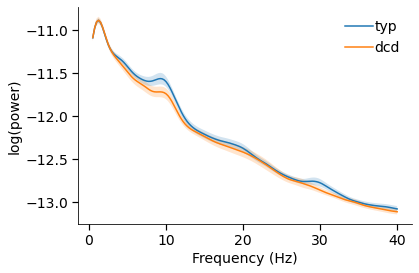

In [19]:
typ_c_psds=np.mean(np.log10(sub_psds_task_typ[:,c_chan_idx,:]),axis=1)
m_typ=np.mean(typ_c_psds,axis=0)
se_typ=np.std(typ_c_psds,axis=0)/np.sqrt(typ_c_psds.shape[0])

dcd_c_psds=np.mean(np.log10(sub_psds_task_dcd[:,c_chan_idx,:]),axis=1)
m_dcd=np.mean(dcd_c_psds,axis=0)
se_dcd=np.std(dcd_c_psds,axis=0)/np.sqrt(dcd_c_psds.shape[0])
plt.plot(freqs,m_typ,label='typ')
plt.fill_between(freqs, m_typ-se_typ, m_typ+se_typ, alpha=.2)
plt.plot(freqs,m_dcd,label='dcd')
plt.fill_between(freqs, m_dcd-se_dcd, m_dcd+se_dcd, alpha=.2)
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('log(power)')


Text(0, 0.5, 'Power')

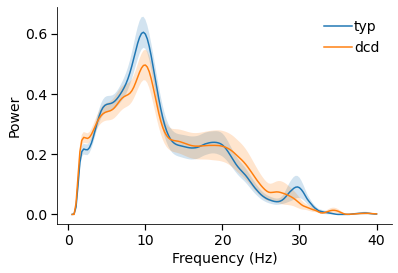

In [20]:
typ_c_psds=np.mean(sub_periodic_typ[:,c_chan_idx,:],axis=1)
typ_c_psds[typ_c_psds<0]=0
m_typ=np.mean(typ_c_psds,axis=0)
se_typ=np.std(typ_c_psds,axis=0)/np.sqrt(typ_c_psds.shape[0])

dcd_c_psds=np.mean(sub_periodic_dcd[:,c_chan_idx,:],axis=1)
dcd_c_psds[dcd_c_psds<0]=0
m_dcd=np.mean(dcd_c_psds,axis=0)
se_dcd=np.std(dcd_c_psds,axis=0)/np.sqrt(dcd_c_psds.shape[0])
plt.plot(freqs,m_typ,label='typ')
plt.fill_between(freqs, m_typ-se_typ, m_typ+se_typ, alpha=.2)
plt.plot(freqs,m_dcd,label='dcd')
plt.fill_between(freqs, m_dcd-se_dcd, m_dcd+se_dcd, alpha=.2)
plt.legend()
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')


In [21]:
typ_c_psds=np.mean(sub_periodic_typ[:,c_chan_idx,:],axis=1)
typ_c_psds[typ_c_psds<0]=0
m_typ=np.mean(typ_c_psds,axis=0)

dcd_c_psds=np.mean(sub_periodic_dcd[:,c_chan_idx,:],axis=1)
dcd_c_psds[dcd_c_psds<0]=0
m_dcd=np.mean(dcd_c_psds,axis=0)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Peak: freq=9.75, val=0.6046121991944933, width=5.5, range=7.0-12.5
Distance to nearest original peak=0.0
Peak: freq=4.5, val=0.30662648993614855, width=4.5, range=2.25-6.75
Distance to nearest original peak=2.5
Peak: freq=19.0, val=0.239099318856473, width=9.0, range=14.5-23.5
Distance to nearest original peak=0.0


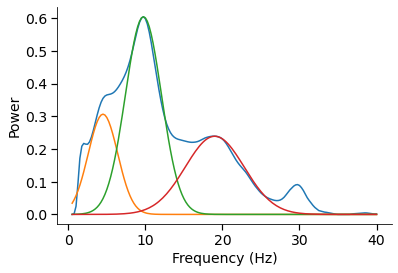

In [22]:
foi_pk_freqs_typ,foi_pk_vals_typ,foi_fwhms_typ,foi_ranges_typ=define_fois(freqs, m_typ)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Peak: freq=10.0, val=0.4959487212582265, width=7.0, range=6.5-13.5
Distance to nearest original peak=0.0
Peak: freq=4.0, val=0.2541147404515176, width=5.0, range=1.5-6.5
Distance to nearest original peak=2.0
Peak: freq=19.5, val=0.2255567514259104, width=9.5, range=14.75-24.25
Distance to nearest original peak=0.5
Peak: freq=28.25, val=0.04527187650948554, width=4.0, range=26.25-30.25
Distance to nearest original peak=1.25


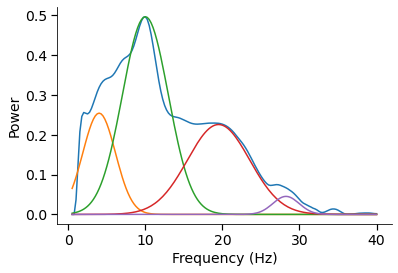

In [23]:
foi_pk_freqs_dcd,foi_pk_vals_dcd,foi_fwhms_dcd,foi_ranges_dcd=define_fois(freqs, m_dcd)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Peak: freq=9.75, val=0.553211105598272, width=6.0, range=6.75-12.75
Distance to nearest original peak=0.0
Peak: freq=4.25, val=0.2820624420982843, width=4.5, range=2.0-6.5
Distance to nearest original peak=2.25
Peak: freq=19.0, val=0.23383760009578264, width=10.0, range=14.0-24.0
Distance to nearest original peak=0.0
Peak: freq=29.5, val=0.059705215814288504, width=3.5, range=27.75-31.25
Distance to nearest original peak=0.25


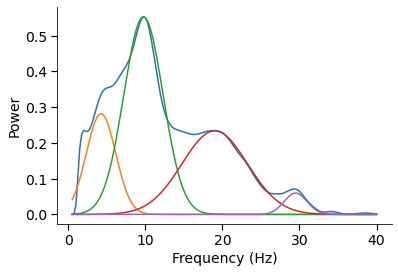

In [24]:
m_all=np.mean(np.vstack([typ_c_psds, dcd_c_psds]),axis=0)
foi_pk_freqs_all,foi_pk_vals_all,foi_fwhms_all,foi_ranges_all=define_fois(freqs, m_all)

In [25]:
fname = "processed_psd_typ.mat"
output_path = op.join('/home/bonaiuto/dcd_bursts/data/derivatives',pipeline,fname)
scipy.io.savemat(output_path,
                 {
                     'frex': freqs,
                     'subj_id': sub_task_typ_ids,
                     'psd': sub_psds_task_typ,
                     'periodic': sub_periodic_typ,
                     'aperiodic': sub_aperiodic_typ,
                     'foi_pk_freqs': foi_pk_freqs_typ,
                     'foi_pk_vals': foi_pk_vals_typ,
                     'foi_fwhms': foi_fwhms_typ,
                     'foi_ranges': foi_ranges_typ
                 })  

In [26]:
fname = "processed_psd_dcd.mat"
output_path = op.join('/home/bonaiuto/dcd_bursts/data/derivatives',pipeline,fname)
scipy.io.savemat(output_path,
                 {
                     'frex': freqs,
                     'subj_id': sub_task_dcd_ids,
                     'psd': sub_psds_task_dcd,
                     'periodic': sub_periodic_dcd,
                     'aperiodic': sub_aperiodic_dcd,
                     'foi_pk_freqs': foi_pk_freqs_dcd,
                     'foi_pk_vals': foi_pk_vals_dcd,
                     'foi_fwhms': foi_fwhms_dcd,
                     'foi_ranges': foi_ranges_dcd
                 })  

In [27]:
c_chan_idx

[7, 23]